<a href="https://colab.research.google.com/github/headdown0845/2026_First-semester/blob/main/%EC%9D%B4%ED%98%95%EB%AF%BC2355022_0320%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/ancestor9/data/main/human_data.csv"
df = pd.read_csv(url)

# 전체 컬럼명 출력
print(df.columns)

Index(['Person', 'height', 'weight', 'foot size'], dtype='object')


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [5]:
url = "https://raw.githubusercontent.com/ancestor9/data/main/human_data.csv"
df = pd.read_csv(url)

In [6]:
target_columns = ['height', 'weight', 'foot size']
data_to_scale = df[target_columns]

In [7]:
print(df.columns)

Index(['Person', 'height', 'weight', 'foot size'], dtype='object')


In [8]:
df.head()

,Person,height,weight,foot size
0,female,5.71,115.83,6.90
1,female,5.26,103.99,6.06
2,female,5.46,139.57,6.91
3,female,5.59,130.28,7.01
4,male,6.14,179.61,11.83


In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)

In [13]:
df_scaled = pd.DataFrame(scaled_data, columns=target_columns)

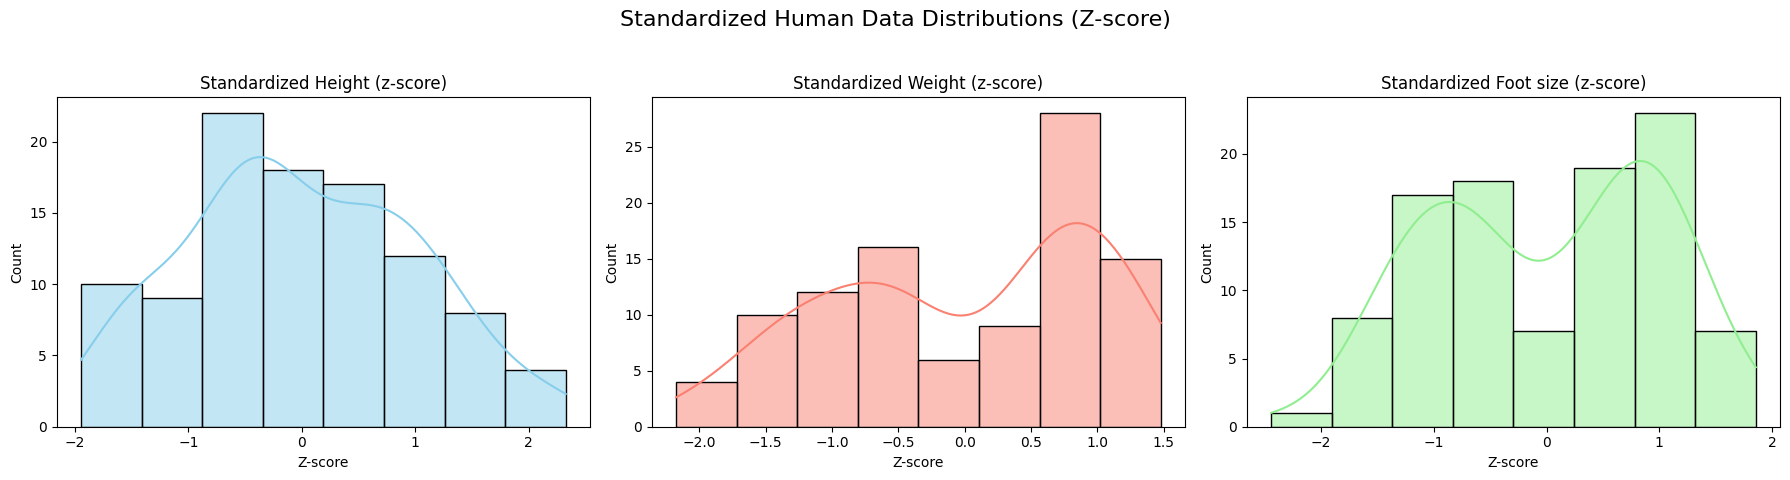

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1행 3열로 변경
fig.suptitle('Standardized Human Data Distributions (Z-score)', fontsize=16)

colors = ['skyblue', 'salmon', 'lightgreen']

for i, col in enumerate(target_columns):
    # 표준화된 데이터 분포를 히스토그램으로 시각화
    sns.histplot(df_scaled[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Standardized {col.capitalize()} (z-score)')
    axes[i].set_xlabel('Z-score')
    axes[i].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

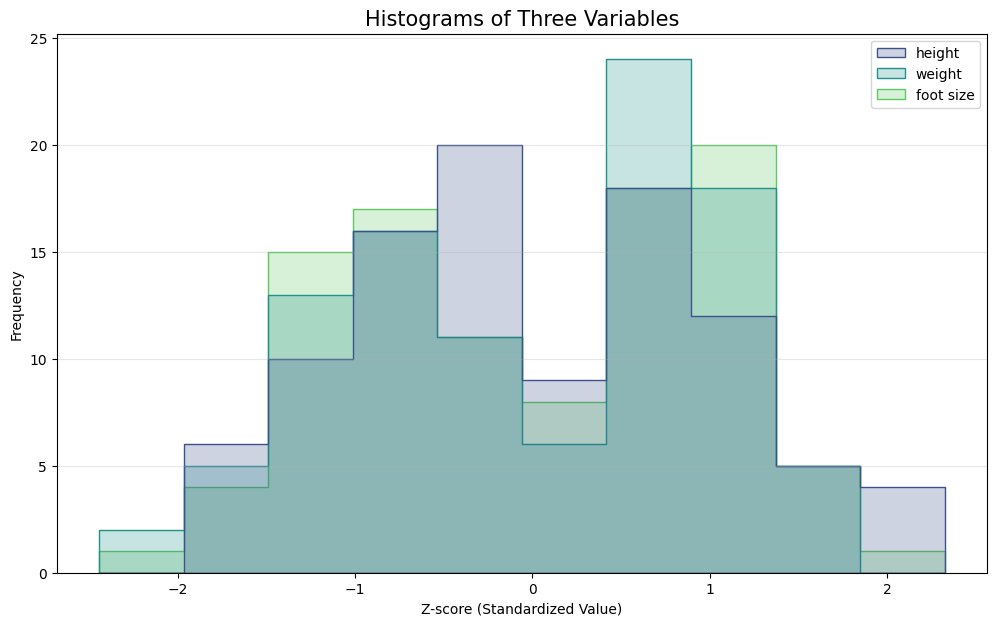

In [21]:
plt.figure(figsize=(12, 7))

# element="step" 또는 alpha(투명도)를 조절하여 겹친 부분을 잘 보이게 합니다.
sns.histplot(df_scaled, element="step", palette="viridis")

plt.title('Histograms of Three Variables', fontsize=15)
plt.xlabel('Z-score (Standardized Value)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

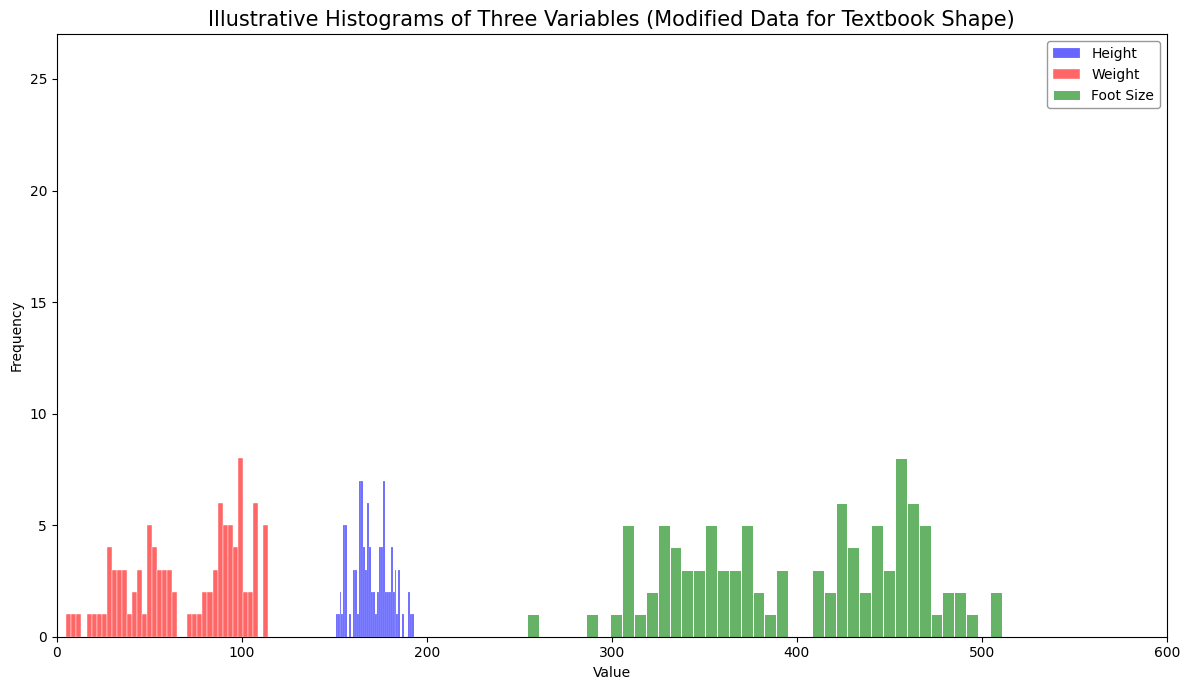

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기 및 기본 수치 확인
url = "https://raw.githubusercontent.com/ancestor9/data/main/human_data.csv"
df = pd.read_csv(url)

target_columns = ['height', 'weight', 'foot size']
original_means = df[target_columns].mean()
original_stds = df[target_columns].std()

# 2. 데이터를 인위적으로 변환 (교과서 이미지 형태 재현용)
# 원본 데이터의 분포 모양은 유지하되, 평균(위치)과 표준편차(폭)만 인위적으로 조절합니다.
df_ill = df.copy()

# 교과서 이미지의 대략적인 수치 목표
# Height: 평균 170, 좁은 폭 (std ~10)
# Weight: 평균 70, 중간 폭 (std ~30)
# Foot Size: 평균 400, 넓은 폭 (std ~60) (교과서의 'Income' 역할)

# Height 변환
df_ill['ill_height'] = (df['height'] - original_means['height']) * (10 / original_stds['height']) + 170
# Weight 변환
df_ill['ill_weight'] = (df['weight'] - original_means['weight']) * (30 / original_stds['weight']) + 70
# Foot Size 변환
df_ill['ill_foot_size'] = (df['foot size'] - original_means['foot size']) * (60 / original_stds['foot size']) + 400

# 3. 시각화 (KDE 제거 및 이미지 스타일 재현)
plt.figure(figsize=(12, 7))

# 제목 및 축 설정 (교과서와 동일하게)
plt.title('Illustrative Histograms of Three Variables (Modified Data for Textbook Shape)', fontsize=15)
plt.xlabel('Value')
plt.ylabel('Frequency')

# X축 범위 및 눈금 설정 (이미지와 동일하게 0~600)
plt.xlim(0, 600)
plt.xticks([0, 100, 200, 300, 400, 500, 600])
plt.ylim(0, 27) # Y축 빈도 범위 조절

# 세 변수의 히스토그램을 동일한 그래프에 겹쳐서 그립니다.
# (kde=False로 설정하여 물결 모양 곡선 제거)

# 1) Height (Blue)
sns.histplot(df_ill['ill_height'], bins=40, color='blue', edgecolor='white', alpha=0.6, kde=False, label='Height')

# 2) Weight (Red)
sns.histplot(df_ill['ill_weight'], bins=40, color='red', edgecolor='white', alpha=0.6, kde=False, label='Weight')

# 3) Foot Size (Green)
sns.histplot(df_ill['ill_foot_size'], bins=40, color='green', edgecolor='white', alpha=0.6, kde=False, label='Foot Size')

# 범례 설정 (우상단)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='gray')

# 레이아웃 조정
plt.tight_layout()
plt.show()

In [16]:
print("표준화 결과 요약")
print(df_scaled.describe().round(4))

표준화 결과 요약
         height    weight  foot size
count  100.0000  100.0000   100.0000
mean    -0.0000   -0.0000    -0.0000
std      1.0050    1.0050     1.0050
min     -1.9447   -2.1736    -2.4421
25%     -0.6347   -0.8144    -0.8530
50%     -0.1397    0.3033     0.1550
75%      0.6948    0.8784     0.9038
max      2.3251    1.4773     1.8551


In [ ]:
s